## Fine-tuning Evo2 with LoRA for splice-site classification

### Background and motivation

Evo2 is a generative DNA foundation model trained on genomic sequences. This notebook
takes a pretrained Evo2-1B checkpoint and adapts it to a **3-way classification task**:
given a 600 bp window of human DNA, predict whether the central position is an
**acceptor splice site**, a **donor splice site**, or **neither**.

The dataset is the `splice_sites_all` task from the
[Nucleotide Transformer downstream-tasks suite](https://huggingface.co/datasets/InstaDeepAI/nucleotide_transformer_downstream_tasks_revised)
— 30K train / 3K test, fixed-length, balanced 3-class.

### What this notebook demonstrates

1. **Subclassing Megatron's `HyenaModel`** to add a sequence-classification head on
   top of pooled hidden states.
2. **A cross-entropy fine-tune through the megatron-bridge training framework**,
   reusing its distributed, optimizer, scheduler, and checkpoint machinery.
3. **LoRA fine-tuning of the backbone** with attention and MLP projections as adapter
   targets, alongside a **head-only baseline** (frozen backbone, trainable head) for
   comparison.
4. **Trainable-parameter accounting** broken down by adapter vs. head.
5. **Test-set evaluation:** load the trained adapter + head checkpoint, then report
   confusion matrix, per-class precision / recall / F1, and training curves.

### Hardware requirements

Runs on a single 48 GB GPU (A6000 / L40S / A100).

### Package requirements

The Evo2 recipe Docker image already provides PyTorch, transformer-engine, megatron-bridge,
and the bionemo-evo2 package. The cell below installs the remaining lightweight Python
dependencies the notebook uses for data wrangling and evaluation.

In [ ]:
%pip install -q scikit-learn datasets matplotlib tensorboard

In [ ]:
import os
from pathlib import Path


# FAST_CI_MODE shortens dataset and step counts so this notebook can be smoke-tested
# without needing serious compute. Set FAST_CI_MODE=1 in the environment to enable.
FAST_CI_MODE: bool = bool(int(os.environ.get("FAST_CI_MODE", "0")))

CLEANUP: bool = False
if CLEANUP:
    # Training outputs (checkpoints + tb_logs for both experiments) and JSONL splits.
    !rm -rf splice_run
    !rm -f splice_train.jsonl splice_val.jsonl splice_test.jsonl
    # Converted backbone — large (~4 GB) and slow to recreate; comment out to keep it.
    !rm -rf evo2_1b_bf16_mbridge

### Step 1 — Acquire the splice-sites benchmark

The [Nucleotide Transformer downstream-tasks suite](https://huggingface.co/datasets/InstaDeepAI/nucleotide_transformer_downstream_tasks_revised) dataset is published as a single combined dataset across all 18 tasks; we
filter it down to the `splice_sites_all` task. Each row has a `sequence`, a `name`
(genomic coordinate), an integer `label` (0–2), and a `task` string.

The standard NT convention for `splice_sites_all` is `0 = no-splice`, `1 = acceptor`,
`2 = donor`. The dataset file does not carry these names directly — we hard-code them
below for legible plot axes. If you see a permuted confusion matrix at the end, the
underlying mapping has shifted in a future release; flip the names list and re-run.

In [2]:
from datasets import load_dataset


DATASET_REPO = "InstaDeepAI/nucleotide_transformer_downstream_tasks_revised"
DATASET_REVISION = "851f9946252e90c665cdb3cc3eedb78f1f26197c"  # 2025-06-30

# All 18 tasks ship in one combined dataset; filter to splice_sites_all.
raw = load_dataset(DATASET_REPO, revision=DATASET_REVISION)
print(raw)

splice = raw.filter(lambda ex: ex["task"] == "splice_sites_all")
print("\nFiltered to splice_sites_all:")
print(splice)

LABEL_NAMES = ["no-splice", "acceptor", "donor"]  # NT convention
print("Class names:", LABEL_NAMES)
print("Number of classes:", len(LABEL_NAMES))

DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 493242
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 38822
    })
})

Filtered to splice_sites_all:
DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 3000
    })
})
Class names: ['no-splice', 'acceptor', 'donor']
Number of classes: 3


### Step 2 — Sanity check: class balance and sequence stats

We verify three properties before training:
- Sequences have a consistent length, so batching and masked pooling are
  straightforward.
- Class counts are roughly balanced (max/min count ratio ≤ 2), so plain accuracy is
  a meaningful primary metric and we don't need class-weighted loss.
- A held-out validation slice can be carved off the training set, since the benchmark
  ships only train/test.

In [3]:
import warnings

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


train_df = splice["train"].to_pandas()
test_df = splice["test"].to_pandas()

assert len(set(train_df["sequence"].str.len())) == 1, "Expected fixed-length sequences."
SEQ_BP = int(train_df["sequence"].str.len().iloc[0])
print(f"All sequences are {SEQ_BP} bp.")


def _imbalance_ratio(df: pd.DataFrame) -> float:
    """Return max/min count across labels — 1.0 means perfectly balanced."""
    counts = df["label"].value_counts()
    return float(counts.max() / counts.min())


print("\nTrain class counts:")
print(train_df["label"].value_counts().rename(index=dict(enumerate(LABEL_NAMES))))
print(f"  imbalance ratio = {_imbalance_ratio(train_df):.2f}")
print("\nTest  class counts:")
print(test_df["label"].value_counts().rename(index=dict(enumerate(LABEL_NAMES))))
print(f"  imbalance ratio = {_imbalance_ratio(test_df):.2f}")

# Soft sanity check: warn if the data is severely imbalanced. With the
# splice_sites_all task this should be ~1.03; if it suddenly jumps, the dataset has
# changed and the metric/loss choices below should be reconsidered.
IMBALANCE_THRESHOLD = 2.0
for name, df in [("train", train_df), ("test", test_df)]:
    ratio = _imbalance_ratio(df)
    if ratio >= IMBALANCE_THRESHOLD:
        warnings.warn(
            f"{name} classes are imbalanced (ratio = {ratio:.2f} ≥ {IMBALANCE_THRESHOLD}). "
            "Plain accuracy will be misleading; consider class-weighted loss or per-class metrics."
        )

# Carve a stratified 10% validation split from the training set.
train_df_s, val_df_s = train_test_split(train_df, test_size=0.10, stratify=train_df["label"], random_state=12342)

# Smaller subsets in fast-CI mode so the notebook runs end-to-end in <5 minutes.
if FAST_CI_MODE:
    train_df_s = train_df_s.groupby("label", group_keys=False).apply(
        lambda g: g.sample(min(len(g), 200), random_state=1)
    )
    val_df_s = val_df_s.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 60), random_state=1))
    test_df = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 60), random_state=1))

print(f"\nUsing  train/val/test = {len(train_df_s)}/{len(val_df_s)}/{len(test_df)}")

All sequences are 600 bp.

Train class counts:
label
donor        10107
acceptor     10047
no-splice     9846
Name: count, dtype: int64
  imbalance ratio = 1.03

Test  class counts:
label
no-splice    1029
donor        1019
acceptor      952
Name: count, dtype: int64
  imbalance ratio = 1.08

Using  train/val/test = 27000/3000/3000


### Step 3 — Persist the splits as JSONL

We write each split to a JSONL file with `{sequence, label}` per line so the splits can
be inspected, re-shuffled, or fed back into a CLI run without re-downloading the dataset.

In [4]:
import json


def to_jsonl(df: pd.DataFrame, path: str) -> None:
    """Write each row of ``df`` as a JSONL record with sequence and label fields."""
    with open(path, "w") as f:
        f.writelines(
            json.dumps({"sequence": str(row.sequence).upper(), "label": int(row.label)}) + "\n"
            for row in df.itertuples(index=False)
        )
    print(f"  wrote {path}: {len(df)} examples")


to_jsonl(train_df_s, "splice_train.jsonl")
to_jsonl(val_df_s, "splice_val.jsonl")
to_jsonl(test_df, "splice_test.jsonl")

  wrote splice_train.jsonl: 27000 examples
  wrote splice_val.jsonl: 3000 examples
  wrote splice_test.jsonl: 3000 examples


### Step 4 — Download the Evo2-1B checkpoint and convert to MBridge

The pretrained Evo2-1B checkpoint is downloaded and converted from NeMo2 to the MBridge format expected by the trainer.

In [5]:
from bionemo.core.data.load import load
from bionemo.core.utils.subprocess_utils import run_subprocess_safely
from bionemo.evo2.data.dataset_tokenizer import DEFAULT_HF_TOKENIZER_MODEL_PATH_512


mbridge_ckpt_path = Path("evo2_1b_bf16_mbridge")
if not mbridge_ckpt_path.exists():
    nemo2_ckpt_path = load("evo2/1b-8k-bf16:1.0")
    convert_cmd = f"""evo2_convert_nemo2_to_mbridge \
        --nemo2-ckpt-dir {nemo2_ckpt_path} \
        --mbridge-ckpt-dir {mbridge_ckpt_path} \
        --model-size evo2_1b_base \
        --mixed-precision-recipe bf16_mixed \
        --seq-length 8192 \
        --tokenizer-path {DEFAULT_HF_TOKENIZER_MODEL_PATH_512}"""
    print(f"Running:\n{convert_cmd}")
    result = run_subprocess_safely(convert_cmd)

print(f"MBridge checkpoint: {mbridge_ckpt_path.absolute()}")

MBridge checkpoint: /workspace/bionemo/examples/evo2_1b_bf16_mbridge


### Step 5 — Configure run paths and shared hyperparameters

Hyperparameters and output directories shared by both training runs below.

In [13]:
import math

import torch


SEQ_LEN_TOKENS = ((SEQ_BP + 7) // 8) * 8
print(f"Padding to {SEQ_LEN_TOKENS} tokens (raw sequence is {SEQ_BP} bp).")

NUM_GPUS = max(1, torch.cuda.device_count())
TRAIN_ITERS_BASELINE = 40 if FAST_CI_MODE else 1000
TRAIN_ITERS_LORA = 40 if FAST_CI_MODE else 1000
MICRO_BATCH_SIZE_BASELINE = 128
MICRO_BATCH_SIZE_LORA = 32
GRAD_ACCUM_STEPS = 1
GLOBAL_BATCH_SIZE_BASELINE = MICRO_BATCH_SIZE_BASELINE * NUM_GPUS * GRAD_ACCUM_STEPS
GLOBAL_BATCH_SIZE_LORA = MICRO_BATCH_SIZE_LORA * NUM_GPUS * GRAD_ACCUM_STEPS

EVAL_ITERS_BASELINE = math.ceil(len(val_df_s) / GLOBAL_BATCH_SIZE_BASELINE)
EVAL_ITERS_LORA = math.ceil(len(val_df_s) / GLOBAL_BATCH_SIZE_LORA)

SAVE_INTERVAL_BASELINE = max(TRAIN_ITERS_BASELINE // 5, 1)
SAVE_INTERVAL_LORA = max(TRAIN_ITERS_LORA // 5, 1)

DECAY_STEPS_LORA = 100000

RESULT_DIR = Path("splice_run").absolute()
EXP_BASELINE = "baseline_head_only"
EXP_LORA = "lora_finetune"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

Padding to 600 tokens (raw sequence is 600 bp).


### Optional — Weights & Biases logging

The cells below send training metrics to [Weights & Biases](https://wandb.ai/) when `WANDB_PROJECT` is set. Leave it as `None` to skip W&B entirely.

Paste your key there, or run `wandb login` in a terminal before launching the notebook.

In [ ]:
WANDB_PROJECT = None  # e.g. "evo2-lora-splice"; None disables wandb entirely.
WANDB_ENTITY = None  # e.g. "your-team"
WANDB_RUN_NAME_BASELINE = None  # defaults to EXP_BASELINE when None
WANDB_RUN_NAME_LORA = None  # defaults to EXP_LORA when None

# Optional inline API key. Prefer setting WANDB_API_KEY in your shell or running
# `wandb login` before launching the notebook.
WANDB_API_KEY = None
if WANDB_API_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY


def _wandb_flags(run_name):
    """Build the wandb CLI flag string passed to evo2_classifier.py, or '' when disabled."""
    if not WANDB_PROJECT:
        return ""
    parts = [f"--wandb-project {WANDB_PROJECT}"]
    if WANDB_ENTITY:
        parts.append(f"--wandb-entity {WANDB_ENTITY}")
    if run_name:
        parts.append(f"--wandb-run-name {run_name}")
    return " " + " ".join(parts)


WANDB_FLAGS_BASELINE = _wandb_flags(WANDB_RUN_NAME_BASELINE)
WANDB_FLAGS_LORA = _wandb_flags(WANDB_RUN_NAME_LORA)

### Step 6 — Head-only baseline

The pretrained backbone is frozen and only the classification head is trained. This is the bar that LoRA needs to beat.

In [15]:
from bionemo.core.utils.subprocess_utils import run_subprocess_safely


baseline_cmd = f"""torchrun --nproc_per_node={NUM_GPUS} evo2_classifier.py \
    --train-jsonl splice_train.jsonl \
    --val-jsonl   splice_val.jsonl \
    --test-jsonl  splice_test.jsonl \
    --base-ckpt-dir {mbridge_ckpt_path} \
    --result-dir {RESULT_DIR} \
    --experiment-name {EXP_BASELINE} \
    --num-classes {len(LABEL_NAMES)} \
    --seq-length-tokens {SEQ_LEN_TOKENS} \
    --train-iters {TRAIN_ITERS_BASELINE} \
    --global-batch-size {GLOBAL_BATCH_SIZE_BASELINE} \
    --micro-batch-size {MICRO_BATCH_SIZE_BASELINE} \
    --lr 1e-3 --min-lr 1e-4 --warmup-iters 20 \
    --eval-interval {min(TRAIN_ITERS_BASELINE // 4, 25)} \
    --eval-iters {EVAL_ITERS_BASELINE} \
    --save-interval {SAVE_INTERVAL_BASELINE} {WANDB_FLAGS_BASELINE}"""

print(f"Running:\n{baseline_cmd}\n")
result = run_subprocess_safely(baseline_cmd)
if result["returncode"] != 0:
    print("STDOUT:", result["stdout"][-2000:])
    print("STDERR:", result["stderr"][-2000:])
    raise RuntimeError("Head-only baseline run failed")

Running:
torchrun --nproc_per_node=8 evo2_classifier.py     --train-jsonl splice_train.jsonl     --val-jsonl   splice_val.jsonl     --test-jsonl  splice_test.jsonl     --base-ckpt-dir evo2_1b_bf16_mbridge     --result-dir /workspace/bionemo/examples/splice_run     --experiment-name baseline_head_only     --num-classes 3     --seq-length-tokens 600     --train-iters 1000     --global-batch-size 1024     --micro-batch-size 128     --lr 1e-3 --min-lr 1e-4 --warmup-iters 20     --eval-interval 25     --eval-iters 3     --save-interval 200 



------------------------------------------------------------------------------------------------------------------------------------------------------------------------


INFO:megatron.core.timers:(min, max) time across ranks (ms):


 validation loss at iteration 1000 on test set | ce loss value: 9.293103E-01 | ce loss PPL: 2.532762E+00 | accuracy value: 5.244141E-01 | accuracy PPL: 1.689469E+00 |


    evaluate .......................................: (2017.54, 2018.05)


------------------------------------------------------------------------------------------------------------------------------------------------------------------------


### Step 7 — LoRA fine-tune

LoRA adapters are added to the backbone's attention, MLP, and Hyena-mixer projections. The backbone weights remain frozen and the classification head stays trainable.

In [16]:
lora_cmd = f"""torchrun --nproc_per_node={NUM_GPUS} evo2_classifier.py \
    --train-jsonl splice_train.jsonl \
    --val-jsonl   splice_val.jsonl \
    --test-jsonl  splice_test.jsonl \
    --base-ckpt-dir {mbridge_ckpt_path} \
    --result-dir {RESULT_DIR} \
    --experiment-name {EXP_LORA} \
    --num-classes {len(LABEL_NAMES)} \
    --seq-length-tokens {SEQ_LEN_TOKENS} \
    --train-iters {TRAIN_ITERS_LORA} \
    --global-batch-size {GLOBAL_BATCH_SIZE_LORA} \
    --micro-batch-size {MICRO_BATCH_SIZE_LORA} \
    --lr 5e-4 --min-lr 5e-5 --warmup-iters 30 --decay-steps {DECAY_STEPS_LORA} \
    --eval-interval {min(TRAIN_ITERS_LORA // 4, 25)} \
    --eval-iters {EVAL_ITERS_LORA} \
    --save-interval {SAVE_INTERVAL_LORA} \
    --lora-finetune --lora-dim 16 --lora-alpha 32 --lora-dropout 0.1 {WANDB_FLAGS_LORA}"""

print(f"Running:\n{lora_cmd}\n")
result = run_subprocess_safely(lora_cmd)
if result["returncode"] != 0:
    print("STDOUT:", result["stdout"][-2000:])
    print("STDERR:", result["stderr"][-2000:])
    raise RuntimeError("LoRA fine-tune run failed")

Running:
torchrun --nproc_per_node=8 evo2_classifier.py     --train-jsonl splice_train.jsonl     --val-jsonl   splice_val.jsonl     --test-jsonl  splice_test.jsonl     --base-ckpt-dir evo2_1b_bf16_mbridge     --result-dir /workspace/bionemo/examples/splice_run     --experiment-name lora_finetune     --num-classes 3     --seq-length-tokens 600     --train-iters 1000     --global-batch-size 256     --micro-batch-size 32     --lr 5e-4 --min-lr 5e-5 --warmup-iters 30 --decay-steps 100000     --eval-interval 25     --eval-iters 12     --save-interval 200     --lora-finetune --lora-dim 16 --lora-alpha 32 --lora-dropout 0.1 



------------------------------------------------------------------------------------------------------------------------------------------------------------------------


INFO:megatron.core.timers:(min, max) time across ranks (ms):


 validation loss at iteration 1000 on test set | ce loss value: 2.063068E-01 | ce loss PPL: 1.229130E+00 | accuracy value: 9.651693E-01 | accuracy PPL: 2.625232E+00 |


    evaluate .......................................: (2465.15, 2467.37)


------------------------------------------------------------------------------------------------------------------------------------------------------------------------


### Step 8 — Load the trained classifiers and evaluate on the test set

Run inference with both the head-only and the LoRA checkpoints on the held-out test split, recording predictions and a parameter-count breakdown for the comparison cells below.

In [17]:
from evo2_classifier import count_params_from_checkpoint, predict


def read_split(jsonl_path):
    """Read a JSONL split into ``(sequences, labels)`` lists."""
    seqs, labels = [], []
    with open(jsonl_path) as f:
        for line in f:
            obj = json.loads(line)
            seqs.append(obj["sequence"])
            labels.append(int(obj["label"]))
    return seqs, labels


baseline_ckpt = RESULT_DIR / EXP_BASELINE / "checkpoints"
lora_ckpt = RESULT_DIR / EXP_LORA / "checkpoints"
print(f"Baseline ckpt root: {baseline_ckpt}")
print(f"LoRA ckpt root    : {lora_ckpt}")

test_seqs, test_labels = read_split("splice_test.jsonl")

Baseline ckpt root: /workspace/bionemo/examples/splice_run/baseline_head_only/checkpoints
LoRA ckpt root    : /workspace/bionemo/examples/splice_run/lora_finetune/checkpoints


In [18]:
preds_baseline = predict(trained_ckpt_dir=baseline_ckpt, sequences=test_seqs)["predictions"]
counts_baseline = count_params_from_checkpoint(baseline_ckpt)
acc_baseline = (preds_baseline.numpy() == np.array(test_labels)).mean()
print(f"Head-only baseline test accuracy: {acc_baseline:.4f}")
print(f"  param breakdown: {counts_baseline}")

Head-only baseline test accuracy: 0.5230
  param breakdown: {'total': 1111902723, 'head': 3697923, 'lora_adapters': 0, 'fine_tuned': 3697923, 'fine_tuned_fraction': 0.0033257612590629477}


In [19]:
preds_lora = predict(trained_ckpt_dir=lora_ckpt, sequences=test_seqs)["predictions"]
counts_lora = count_params_from_checkpoint(lora_ckpt)
acc_lora = (preds_lora.numpy() == np.array(test_labels)).mean()
print(f"LoRA + head test accuracy: {acc_lora:.4f}")
print(f"  param breakdown: {counts_lora}")

LoRA + head test accuracy: 0.9663
  param breakdown: {'total': 1124190723, 'head': 3697923, 'lora_adapters': 12288000, 'fine_tuned': 15985923, 'fine_tuned_fraction': 0.014219938550409119}


### Step 9 — Trainable-parameter accounting

With ~1% of the parameters trainable, the LoRA run should clearly beat the head-only baseline.

In [20]:
print(f"{'Mode':<18} {'Test acc':>10}")
print("─" * 32)
print(f"{'head only':<18} {acc_baseline:>10.4f}")
print(f"{'LoRA + head':<18} {acc_lora:>10.4f}")
print()
print(f"LoRA fine-tuned parameters: {counts_lora['fine_tuned']:>12,}")
print(f"  └─ adapters     : {counts_lora['lora_adapters']:>12,}")
print(f"  └─ head         : {counts_lora['head']:>12,}")
print(f"Total parameters          : {counts_lora['total']:>12,}")
print(f"Fine-tuned fraction       : {100 * counts_lora['fine_tuned_fraction']:>11.3f}%")

Mode                 Test acc
────────────────────────────────
head only              0.5230
LoRA + head            0.9663

LoRA fine-tuned parameters:   15,985,923
  └─ adapters     :   12,288,000
  └─ head         :    3,697,923
Total parameters          : 1,124,190,723
Fine-tuned fraction       :       1.422%


### Step 10 — Confusion matrix and full classification report

We score the LoRA + head model on the held-out test split: a three-way confusion
matrix plus per-class precision, recall, and F1.

=== LoRA + head — classification report ===
              precision    recall  f1-score   support

   no-splice      0.942     0.965     0.953      1029
    acceptor      0.963     0.970     0.966       952
       donor      0.995     0.965     0.980      1019

    accuracy                          0.966      3000
   macro avg      0.967     0.966     0.966      3000
weighted avg      0.967     0.966     0.966      3000



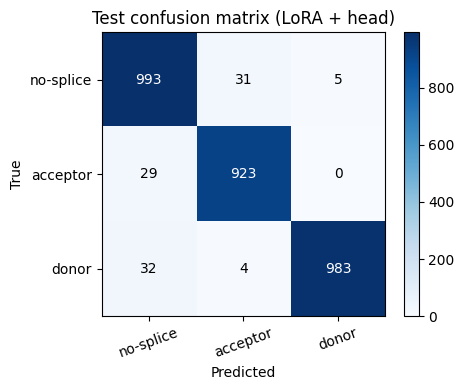

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


preds_np = preds_lora.numpy()
labels_np = np.array(test_labels)

print("=== LoRA + head — classification report ===")
print(classification_report(labels_np, preds_np, target_names=LABEL_NAMES, digits=3))

cm = confusion_matrix(labels_np, preds_np, labels=list(range(len(LABEL_NAMES))))
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABEL_NAMES)))
ax.set_xticklabels(LABEL_NAMES, rotation=20)
ax.set_yticks(range(len(LABEL_NAMES)))
ax.set_yticklabels(LABEL_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
ax.set_title("Test confusion matrix (LoRA + head)")
plt.tight_layout()
plt.show()

### Step 11 — Training curves from TensorBoard

We load the TensorBoard event files written by each run and overlay the training
and validation loss curves from the head-only baseline and the LoRA + head run on a
single plot, so the gap between the two is directly comparable.

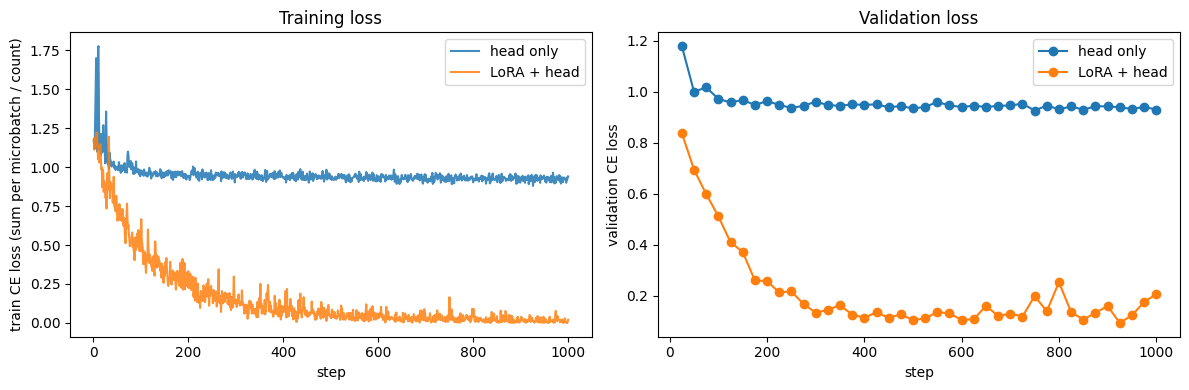

In [22]:
import tensorboard.backend.event_processing.event_accumulator as event_accumulator


def tb_dataframe(experiment_name: str):
    """Read all scalar tags from the latest event file under ``RESULT_DIR/experiment_name``."""
    import pandas as pd

    tb_dir = RESULT_DIR / experiment_name / "tb_logs"
    event_files = sorted(tb_dir.rglob("events.out.tfevents*"))
    if not event_files:
        return None
    ea = event_accumulator.EventAccumulator(str(event_files[-1]), size_guidance={event_accumulator.SCALARS: 0})
    ea.Reload()
    tags = ea.Tags()["scalars"]
    if not tags:
        return None
    all_steps = sorted({event.step for tag in tags for event in ea.Scalars(tag)})
    out = pd.DataFrame({"step": all_steps})
    for tag in tags:
        out[tag] = out["step"].map({e.step: e.value for e in ea.Scalars(tag)})
    return out


df_baseline = tb_dataframe(EXP_BASELINE)
df_lora = tb_dataframe(EXP_LORA)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for df, label in [(df_baseline, "head only"), (df_lora, "LoRA + head")]:
    if df is None:
        continue
    if "ce loss" in df.columns:
        axes[0].plot(df["step"], df["ce loss"], label=label, alpha=0.85)
    if "ce loss validation" in df.columns:
        val = df[["step", "ce loss validation"]].dropna()
        axes[1].plot(val["step"], val["ce loss validation"], marker="o", label=label)

axes[0].set_xlabel("step")
axes[0].set_ylabel("train CE loss (sum per microbatch / count)")
axes[0].set_title("Training loss")
axes[0].legend()
axes[1].set_xlabel("step")
axes[1].set_ylabel("validation CE loss")
axes[1].set_title("Validation loss")
axes[1].legend()
plt.tight_layout()
plt.show()

### Discussion and possible follow-ups

What to look for in the plots and tables:

- **Accuracy gap.** With ~1% of the parameters, LoRA + head should beat head-only by a
  meaningful margin (10-30 points on this task). If the gap is small, either the head-only
  baseline is too capable (try a smaller `--classifier-hidden-size`) or the LoRA budget
  is too small (try `--lora-dim 32` or adding more target modules).
- **Confusion matrix.** Donor↔acceptor confusion is the expected primary error mode —
  both motifs share GT/AG dinucleotide structure. The no-splice class should rarely be
  confused with either.

Possible extensions:

1. **Sweep LoRA targets.** Try attention-only (`linear_qkv,linear_proj`) vs. MLP-only
   (`linear_fc1,linear_fc2`) vs. Hyena mixer-only (`dense_projection,dense`). This
   isolates which sub-architecture in Evo2 is doing the heavy lifting for splice signal.
2. **Bigger backbone.** Re-run with `evo2_7b` once the corresponding classifier provider
   is added — the same `evo2_classifier.py` script handles it once the size key is
   registered in `CLASSIFIER_PROVIDER_OPTIONS`.
3. **Other 3-class tasks.** The Nucleotide Transformer suite also ships
   `enhancers_types` (3-class strong/weak/none). A drop-in change to the dataset filter
   in Step 1 lets you reuse this entire pipeline.